# SentinelOps - EDA (Step 2.1-2.3)
DuckDB windowed queries over Parquet telemetry + anomaly visualization.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
df = con.execute("SELECT * FROM read_parquet('../data/raw/telemetry.parquet')").df()
gt = pd.read_parquet('../data/raw/ground_truth_windows.parquet')
df.head()

,service_name,timestamp,cpu_pct,memory_pct,latency_p50_ms,latency_p95_ms,latency_p99_ms,error_rate_pct,queue_depth,thread_count,is_anomaly_ground_truth
0,checkout-service,2026-07-10 00:00:00,36.490142,48.678325,74.244231,122.879500,175.033374,0.869733,7.017676,49.528040,0
1,checkout-service,2026-07-10 00:05:00,34.745196,45.233070,65.971266,111.859881,166.011882,0.238471,4.147149,49.091538,0
2,checkout-service,2026-07-10 00:10:00,37.262980,50.544407,76.286368,148.332909,204.688860,0.554732,6.163630,45.042785,0
3,checkout-service,2026-07-10 00:15:00,40.048802,46.827163,85.283308,161.670246,224.316390,0.813371,5.393194,50.986269,0
4,checkout-service,2026-07-10 00:20:00,34.936857,49.456981,83.250906,146.946577,208.539264,0.619818,2.746731,51.372867,0


In [2]:
# STEP 2.2 - DuckDB windowed query: rolling stats per service
windowed = con.execute("""
    SELECT
        service_name,
        timestamp,
        cpu_pct,
        latency_p95_ms,
        memory_pct,
        is_anomaly_ground_truth,
        AVG(latency_p95_ms) OVER (
            PARTITION BY service_name ORDER BY timestamp
            ROWS BETWEEN 12 PRECEDING AND CURRENT ROW
        ) AS latency_p95_rolling_mean_1h,
        STDDEV(latency_p95_ms) OVER (
            PARTITION BY service_name ORDER BY timestamp
            ROWS BETWEEN 12 PRECEDING AND CURRENT ROW
        ) AS latency_p95_rolling_std_1h
    FROM read_parquet('../data/raw/telemetry.parquet')
    ORDER BY service_name, timestamp
""").df()
windowed.tail()

,service_name,timestamp,cpu_pct,latency_p95_ms,memory_pct,is_anomaly_ground_truth,latency_p95_rolling_mean_1h,latency_p95_rolling_std_1h
12091,search-service,2026-07-16 23:35:00,40.969394,159.894868,52.320985,0,155.087813,14.606534
12092,search-service,2026-07-16 23:40:00,43.678784,158.732889,49.022862,0,155.589465,14.611501
12093,search-service,2026-07-16 23:45:00,37.687365,162.578491,46.594500,0,155.791185,14.694673
12094,search-service,2026-07-16 23:50:00,35.042472,149.271298,47.033323,0,154.127656,14.052117
12095,search-service,2026-07-16 23:55:00,35.713067,189.029583,48.972526,0,158.672608,15.095147


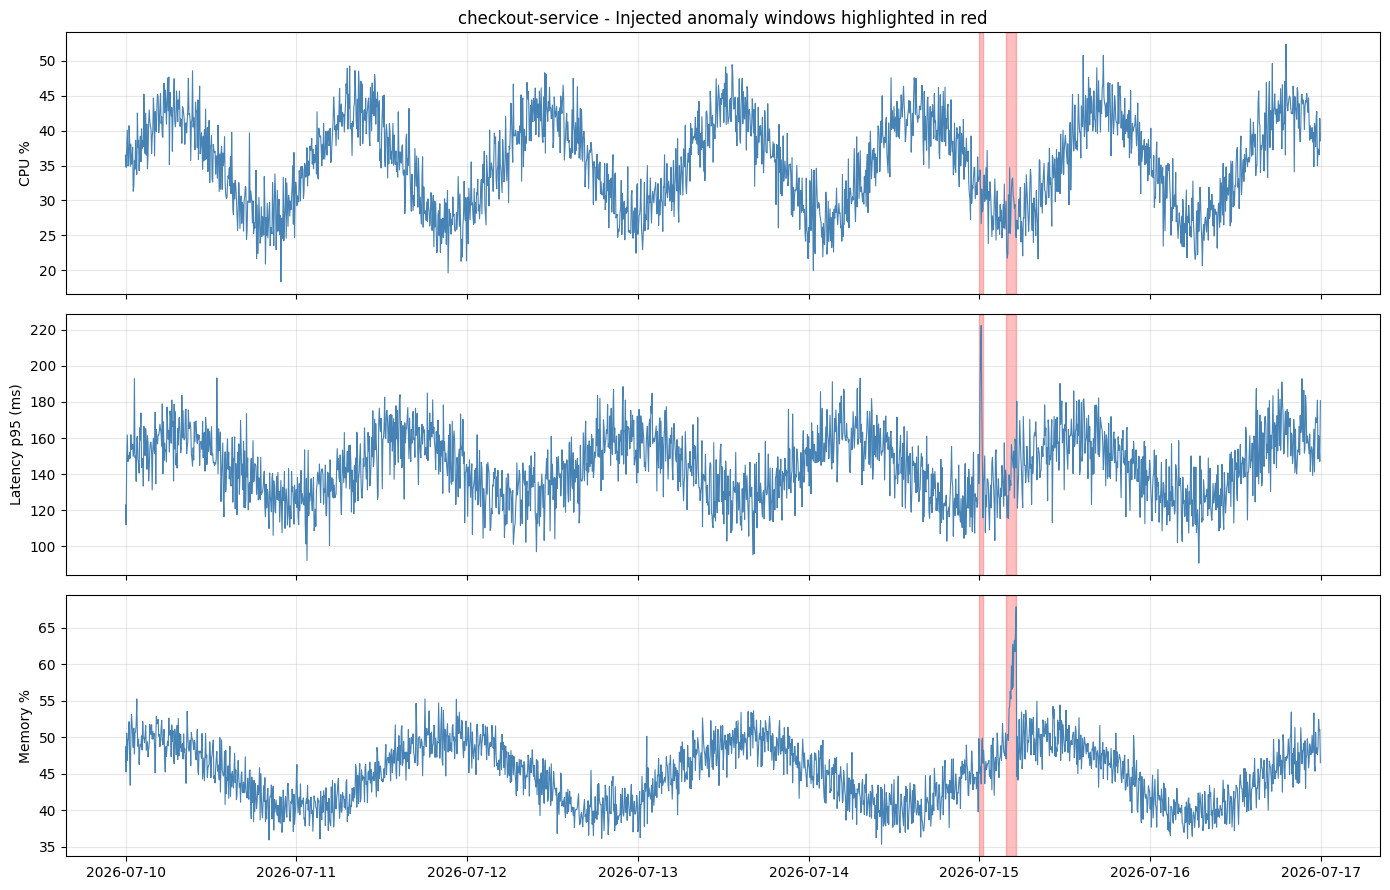

In [3]:
# STEP 2.3 - Visualize injected anomalies vs raw metrics for one service
service = 'checkout-service'
sub = df[df.service_name == service].sort_values('timestamp')
sub_gt = gt[gt.service_name == service]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, col, title in zip(
    axes,
    ['cpu_pct', 'latency_p95_ms', 'memory_pct'],
    ['CPU %', 'Latency p95 (ms)', 'Memory %']
):
    ax.plot(sub['timestamp'], sub[col], linewidth=0.8, color='steelblue')
    for _, w in sub_gt.iterrows():
        ax.axvspan(w['start_timestamp'], w['end_timestamp'], color='red', alpha=0.25)
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)

axes[0].set_title(f'{service} - Injected anomaly windows highlighted in red')
plt.tight_layout()
plt.savefig('../reports/figures/eda_anomaly_overview.png', dpi=150)
plt.show()